<a href="https://colab.research.google.com/github/idarwati/Health-Data-Analytics-Portfolio/blob/Early-Warning-System-Diseases/Early_Warning_System_DBD_dan_Diare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-1693337468.py:22: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start='2019-01-01', periods=60, freq='M')
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


--- 5 Baris Data Pertama ---
            Curah_Hujan       Suhu  Kelembaban  Kasus_DBD
Tanggal                                                  
2019-01-31   209.934283  28.760413   81.582064  34.121765
2019-02-28   222.536891  28.878512   79.868037  27.967901
2019-03-31   262.832999  28.333019   86.130870  30.928837
2019-04-30   303.487403  28.148873   82.064752  42.761102
2019-05-31   289.398466  28.963963   87.445816  37.822533
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.2828 - val_loss: 0.0929
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0438 - val_loss: 0.0515
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0546 - val_loss: 0.0265
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0253 - val_loss: 0.0334
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0272 - val_loss: 0.0290
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0301 - val_loss: 0.0263
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - los

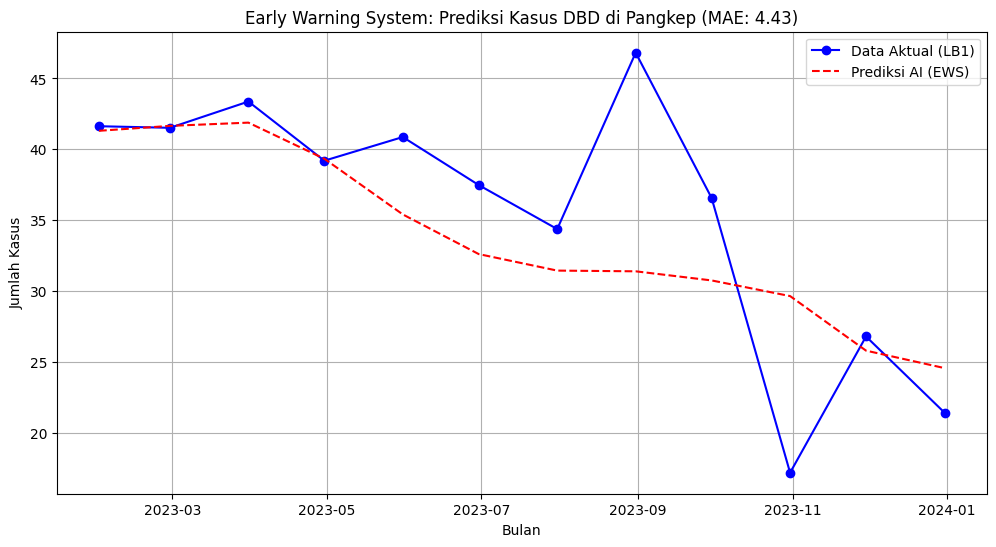

Model selesai dibuat. Grafik menunjukkan perbandingan data asli vs prediksi.


In [ ]:
# ==========================================
# JUDUL: Early Warning System DBD & Diare
# AUTHOR: [Nama Anda]
# METODE: LSTM (Long Short-Term Memory)
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# ---------------------------------------------------------
# 1. DATA GENERATION (Ganti bagian ini dengan Load Data Asli)
# ---------------------------------------------------------
# Simulasi data 5 tahun (60 bulan) untuk wilayah Pangkep
np.random.seed(42)
dates = pd.date_range(start='2019-01-01', periods=60, freq='M')

# Simulasi Iklim (Pola musiman)
hujan = 200 + 150 * np.sin(np.linspace(0, 10, 60)) + np.random.normal(0, 20, 60) # Curah hujan mm
suhu = 27 + 2 * np.cos(np.linspace(0, 10, 60)) + np.random.normal(0, 0.5, 60)    # Suhu Celcius
kelembaban = 80 + 10 * np.sin(np.linspace(0, 10, 60)) + np.random.normal(0, 2, 60) # %

# Simulasi Kasus DBD (Berkorelasi dengan Hujan ada lag waktu)
# Asumsi: Hujan tinggi bulan lalu -> Nyamuk berkembang -> Kasus naik bulan ini
kasus_dbd = 10 + 0.1 * hujan + np.random.normal(0, 5, 60)
kasus_dbd = np.maximum(kasus_dbd, 0) # Tidak boleh minus

# Membuat DataFrame
df = pd.DataFrame({
    'Tanggal': dates,
    'Curah_Hujan': hujan,
    'Suhu': suhu,
    'Kelembaban': kelembaban,
    'Kasus_DBD': kasus_dbd
})
df.set_index('Tanggal', inplace=True)

print("--- 5 Baris Data Pertama ---")
print(df.head())

# ---------------------------------------------------------
# 2. PREPROCESSING
# ---------------------------------------------------------
# Normalisasi data (Skala 0-1) agar LSTM bekerja optimal
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)

# Fungsi untuk mengubah data menjadi format Supervised Learning (X, y)
# Kita menggunakan data 3 bulan terakhir (look_back) untuk memprediksi bulan depan
def create_dataset(dataset, look_back=3):
    X, Y = [], []
    for i in range(len(dataset) - look_back - 1):
        a = dataset[i:(i + look_back), :]
        X.append(a)
        Y.append(dataset[i + look_back, 3]) # Indeks 3 adalah kolom Kasus_DBD
    return np.array(X), np.array(Y)

look_back = 3
X, y = create_dataset(scaled_data, look_back)

# Split Data (80% Train, 20% Test)
train_size = int(len(X) * 0.8)
test_size = len(X) - train_size
X_train, X_test = X[0:train_size], X[train_size:len(X)]
y_train, y_test = y[0:train_size], y[train_size:len(X)]

# ---------------------------------------------------------
# 3. MEMBANGUN MODEL LSTM
# ---------------------------------------------------------
model = Sequential()
# Input shape: (time_steps, features)
model.add(LSTM(50, return_sequences=True, input_shape=(look_back, df.shape[1])))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(1)) # Output layer (Prediksi jumlah kasus)

model.compile(loss='mean_squared_error', optimizer='adam')

# Training
history = model.fit(X_train, y_train, epochs=50, batch_size=4, validation_data=(X_test, y_test), verbose=1)

# ---------------------------------------------------------
# 4. EVALUASI & VISUALISASI
# ---------------------------------------------------------
# Prediksi
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Kembalikan ke skala asli (Inverse Transform)
# Kita perlu trik karena scaler mengharapkan 4 kolom, tapi output prediksi cuma 1 kolom
def inverse_transform_prediction(pred, original_X):
    # Buat placeholder kosong dengan bentuk sama seperti data asli
    dummy = np.zeros((len(pred), df.shape[1]))
    dummy[:, 3] = pred[:, 0] # Masukkan prediksi ke kolom DBD
    return scaler.inverse_transform(dummy)[:, 3]

y_train_inv = inverse_transform_prediction(train_predict, X_train)
y_test_inv = inverse_transform_prediction(test_predict, X_test)
y_actual_inv = inverse_transform_prediction(y_test.reshape(-1, 1), X_test)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df.index[-len(y_actual_inv):], y_actual_inv, label='Data Aktual (LB1)', color='blue', marker='o')
plt.plot(df.index[-len(y_test_inv):], y_test_inv, label='Prediksi AI (EWS)', color='red', linestyle='--')
plt.title(f'Early Warning System: Prediksi Kasus DBD di Pangkep (MAE: {mean_absolute_error(y_actual_inv, y_test_inv):.2f})')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Kasus')
plt.legend()
plt.grid(True)
plt.show()

print("Model selesai dibuat. Grafik menunjukkan perbandingan data asli vs prediksi.")